# Week 04 Lab 03: Create_agent, the agent layer  
In the last Lab a tool loop was built by hand in LangGraph: a chatbot node, a conditional edge, and an edge back again. In this Lab all of that will be done from a single function call.  
`create_agent` is `Layer 3`. Hand it a model, some tools and a prompt, and it builds the agent loop. This is the next step along the control to convenience spine: you hand the loop to the framework and write far less code. The part that ties this whole week together is that what it builds is a LangGraph graph, the very kind assembled in Lab02 by hand yesterday.

In [2]:
# Imports and environment first, all in one place.
from dotenv import load_dotenv
from IPython.display import Image, display
from pydantic import BaseModel, Field
from langchain.agents  import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langchain_mcp_adapters.client import MultiServerMCPClient

load_dotenv(override = True)

True

## Part 1: the simplest Agent  
An agent in its plainest form is a model with a prompt. Pass the model as a string in the form `provider:model`, and a system prompt to set its character.

In [5]:
agent = create_agent(
    model = 'openai:gpt-4o-mini',
    
    system_prompt = 'You are a helpful AI assistant who answers concisely.'
)

result = agent.invoke({'messages' : [{'role' : 'user', 'content' : 'What is the Model Context Protocol, in two sentences?'}]})
print(result['messages'][-1].content)

The Model Context Protocol (MCP) is a framework designed to facilitate the integration and interaction of artificial intelligence models with their environments by establishing a standard for context management. It aims to enhance the adaptability and effectiveness of AI systems by allowing them to better understand and respond to their operational contexts and user needs.


### And the async twin: ainvoke  
Everything in LangChain that can `invoke` can also `ainvoke`: same arguments, same result , awaited. This is simply the right way to call an agent from async code. It will matter at the end of the lab, where the browser tools only speak async.

In [6]:
result = await agent.ainvoke({'messages' : [{'role' : 'user', 'content' : 'In one sentence: why does async code suit agents so well?'}]})
print(result['messages'][-1].content)

Async code suits agents well because it allows them to handle multiple tasks concurrently without blocking, enabling efficient interaction in environments with unpredictable responses or events.


## Part 2: tools  
To make the agent useful, we give it tools. These are the same `@tool` function from Day1. We pass them in a list, and the agent runs the whole tool loop for us.

In [8]:
@tool
def get_weather(city: str) -> str:
    """Return today's weather for a city."""
    pretend = {'London' : 'rainy, 14 degrees', 'Rome' : 'sunny, 27 degrees'}
    return pretend.get(city, 'clear, 20 degrees')

@tool
def get_population(city: str) -> str:
    """Return the population of the city."""
    pretend = {'London' : '8.9 million', 'Rome' : '2.8 million'}
    return pretend.get(city, 'Unknown')

agent = create_agent(
    model = 'openai:gpt-4o-mini',
    tools = [get_weather, get_population],
    system_prompt = 'You are a travel assistant. Use your tools to answer questions about cities.',
)

result = agent.invoke({'messages' : [{'role' : 'user', 'content' : 'What is the weather and population of Rome?'}]})
print(result['messages'][-1].content)

The weather in Rome is sunny with a temperature of 27 degrees. The population of Rome is approximately 2.8 million people.


## The Reveal: it is a LangGraph graph  
Now that agent has tools, lets draw it. Because `create_agent` returns a compiled LangGraph graph, we can render it with exactly the same call we used yesterday. Look at the shape: a model node, a tools node, and the conditional loop between them. This is the graph built by hand on day2 labs.


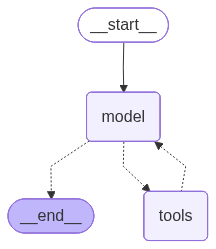

In [9]:
display(Image(agent.get_graph().draw_mermaid_png()))

## Part 3: memory  
By default each call to `invoke` is a fresh start. To remember a conversation, agent handed wiht a checkpointer, exactly as previous lab, and pass a `thread_id` so it knows which conversation is referred..

In [11]:
memory_agent = create_agent(
    model= 'openai:gpt-4o-mini',
    tools = [get_weather],
    checkpointer = MemorySaver()
)
config = {'configurable' : {'thread_id' : 'trip-planning'}}
memory_agent.invoke({
    'messages' : [{
        'role' : 'user',
        'content' : 'What is the weather like where I am going on my trip?'
    }]
}, config = config)

print(result['messages'][-1].content)

The weather in Rome is sunny with a temperature of 27 degrees. The population of Rome is approximately 2.8 million people.


## Part 04: Structured output  
To get a typed object back rather than pros, pass a Pydantic model as `response_format`. The agent still does its work and uses its tools, then fills in your object. Read it from the `structured_response` key.

In [13]:
class CityReport(BaseModel):
    city: str = Field(description = 'The city name')
    weather: str = Field(description = 'A short weather description')
    population: str = Field(description = 'The population')

report_agent = create_agent(
    model = 'openai:gpt-4o-mini',
    tools = [get_weather, get_population],
    response_format = CityReport,
)

result = report_agent.invoke({'messages' : [{
    'role' : 'user',
    'content' : 'Give me a report on London'
}]})
report = result['structured_response']
print(report)
print('Just the weather: ', report.weather)

city='London' weather='rainy, 14 degrees' population='8.9 million'
Just the weather:  rainy, 14 degrees


## Part 5: middleware  
Middleware is a powerful feature to shape an agent's behavior. It lets you run your own code at fixed points in the loop: before the model is called, after it answers, or around each tool call.  
Here is a small piece of custom middleware that prints every tool call as it happens, so you can watch the agent at work. The `wrap_tool_call` decorator wraps each tool call: log it, then call `handler` to let it proceed.

In [14]:
@wrap_tool_call
def log_tool_calls(request, handler):
    call = request.tool_call
    print(f"[middleware] calling {call['name']} with {call['args']}")
    return handler(request)

watched_agent = create_agent(
    model = 'openai:gpt-4o-mini',
    tools = [get_weather, get_population],
    middleware = [log_tool_calls],
    system_prompt = 'You are a travel assistant. Use your tools.'

)
result = watched_agent.invoke({'messages' :[{'role' : 'user', 'content' : 'Weather and population of London and Rome'}]})
print(result['messages'][-1].content)

[middleware] calling get_weather with {'city': 'London'}
[middleware] calling get_weather with {'city': 'Rome'}
[middleware] calling get_population with {'city': 'London'}
[middleware] calling get_population with {'city': 'Rome'}
Here's the information you requested:

**London**:
- Weather: Rainy, 14 degrees Celsius
- Population: Approximately 8.9 million

**Rome**:
- Weather: Sunny, 27 degrees Celsius
- Population: Approximately 2.8 million


LangChain also ships a range of ready made middleware, including `SummarizationMiddleware` to keep long conversation within the context window, `PIIMiddleware` to redact sensitive data, retry and call-limit middleware, and `HumanInTheLoopMiddleware` to pause fo human approval.

## Before Part 6: word about Node and Playwright  
The last part of this lab uses tools that live in a separate program, an MCP Server, and that program runs on Node. Two quick checks before moving to next step..  
First, Node itsel; Node v22 or later is required. If the cell below fails, install Node with one command:
- **Windows**, in PowerShell: `winget install OpenJS.NodeJS.LTS`
- **Mac**, in Terminal: `brew install node`
- **Linux**, or if neither works for you: see the guide at [setup/SETUP-node.md](../setup/SETUP-node.md) 
After Installing, quit the IDE and start it again, then reopen this notebook and re-run the lab from the top. That full restart matters: a freshly installed Node is invisible to a notebook that was already running, and restarting just the kernel is not enough.

In [17]:
!node --version
!npx --version

v24.18.0
11.16.0


Second, Playwright, Microsoft's browser automation framework. There is nothing to install: `npx` fetches it on demand, and it drives the copy of chrome already on your machine. Chrome does not need to be running; Playwright launches its own.  
The cell below proves the whole chain with no AI involved at all: Node runs Playwright, Playwright opens Chrome, loads Hacker News, and saves a screenshot. The first run takes a little longer while npx downloads the package.  
If it complains that Chrome is not found, either install Chrome manually or run `npx playwright install chrome` in a terminal, then try again.

Navigating to https://news.ycombinator.com/
Capturing screenshot into playwright_check.png


npm notice
npm notice New minor version of npm available! 11.16.0 -> 11.18.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.18.0
npm notice To update run: npm install -g npm@11.18.0
npm notice


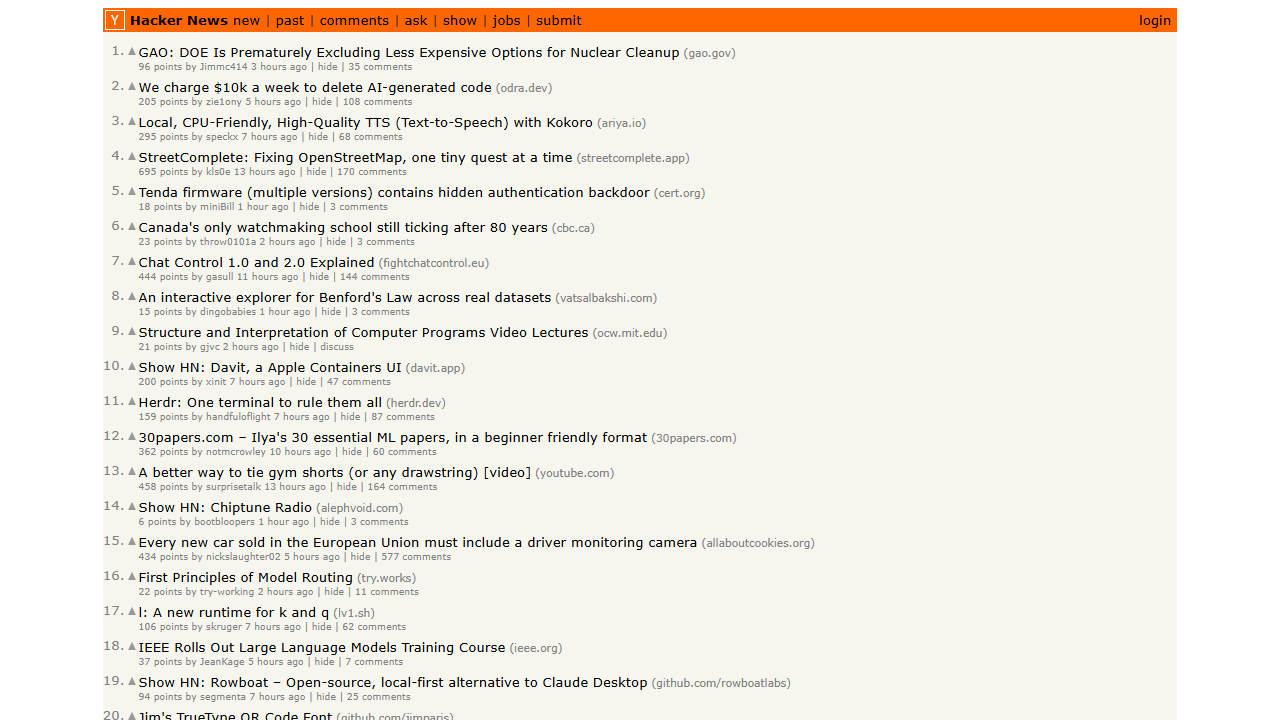

In [18]:
!npx -y playwright@latest screenshot --channel=chrome https://news.ycombinator.com/ playwright_check.png
display(Image('playwright_check.png'))

## Part 6: an MCP server, and a real browser  
Tools do not have to be Python functions you write. The Model Contxt Protocol is a standard way for agents to use tools that live in a separate server. LangChain loads those tools with `langchain-mcp-adapters`, and from the agent's point of view they are just tools like any other.  
We will connect to Microsoft's Playwright MCP server, which drives the same real browser you just smoke-tested. It runs headed by default, so you can watch it work; on a Linux box with no display it quietly falls back to headless. Because these tools talk to a separate process, they are async, so we load them with `await` and run the agent with `ainvoke`.  
#### One adjustment for windows.  
When Python launches another program, it hands that program a place to write its error messages. Inside a Jupyter notebook on Windows, that place is not a real file, and the library that launches MCP server trips over it (a known issue in the MCP Python SDK, which only shows up in notebooks, never in ordinary Python scripts). The cell below points the MCP server's error log somewhere safe before we connect. On Mac and Linux it does nothing at all, so run it either way and carry on.

In [22]:
import sys
if sys.platform == 'win32':
    import subprocess
    from functools import partial
    import langchain_mcp_adapters.sessions as mcp_sessions

    mcp_sessions.stdio_client = partial(mcp_sessions.stdio_client, errlog = subprocess.DEVNULL)
    print("Applied the Windows adjustment")
else:
    print("Not Windows, so nothing to be done.")

Applied the Windows adjustment


In [24]:
client = MultiServerMCPClient({
    "playwright" : {
        'transport' : 'stdio',
        'command' : 'npx',
        'args' : ['-y', '@playwright/mcp@latest', '--isolated'],
    }
})

browser_tools = await client.get_tools()
print(f"Loaded {len(browser_tools)} browser tools:")
for tool in browser_tools:
    print(f" -", tool.name)

Loaded 23 browser tools:
 - browser_close
 - browser_resize
 - browser_console_messages
 - browser_handle_dialog
 - browser_evaluate
 - browser_file_upload
 - browser_drop
 - browser_fill_form
 - browser_press_key
 - browser_type
 - browser_navigate
 - browser_navigate_back
 - browser_network_requests
 - browser_network_request
 - browser_run_code_unsafe
 - browser_take_screenshot
 - browser_snapshot
 - browser_click
 - browser_drag
 - browser_hover
 - browser_select_option
 - browser_tabs
 - browser_wait_for


Now hand those tools to an ordinary `create_agent` and ask it to visit Hacker News and report what it finds. Watch the browser window open and navigate on its own.

In [26]:
browser_agent = create_agent(
    model = 'openai:gpt-4o',
    tools = browser_tools,
    system_prompt = 'You are a web research assistant. Use the browser tools to complete the task, then report clearly.'
)

result = await browser_agent.ainvoke({'messages' : [{'role' : 'user',
'content' : 'Go to "https://news.ycombinator.com" and tell me the titles of the top three stories on the front page'}]})
print(result['messages'][-1].content)

I encountered an issue while trying to retrieve the titles from Hacker News. Unfortunately, I'm unable to extract the information at this moment. You might want to try checking the website directly through your browser.


## Recap  
In one Lab an agent was buil in a single line, seen that it is really a LangGraph graph, given it tools, memory and structured output, shaped it with middleware, and let it drive a real browser through an MCP server. This is the layer mostly used.